## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [46]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [47]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')

df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [48]:
# TODO: check the dataset size with df.shape

df.shape

(3900, 19)

In [49]:
# TODO: drop the Customer ID column  
print("Before: ", df.columns)
df = df.drop(columns=['Customer ID'])
print("After: ", df.columns)

Before:  Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='str')
After:  Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Payment Method', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Preferred Payment Method', 'Frequency of Purchases'],
      dtype='str')


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [50]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [51]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [52]:
# TODO: check duplicate rows with df.duplicated().sum()
print(df.duplicated().sum())

0


In [53]:
# TODO: univariate — describe numeric columns
df.describe(include='number')

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [54]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

In [55]:
male_df.tail()
female_df.tail()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly


## **EDA**

### **Item Purchased**

In [56]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
#dùng để đặt lại thứ tự sau khi đã lọc file chia nam chia nữ

df = df.value_counts().reset_index()

df.tail()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,count
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,1
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,1
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,1
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly,1
3899,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly,1


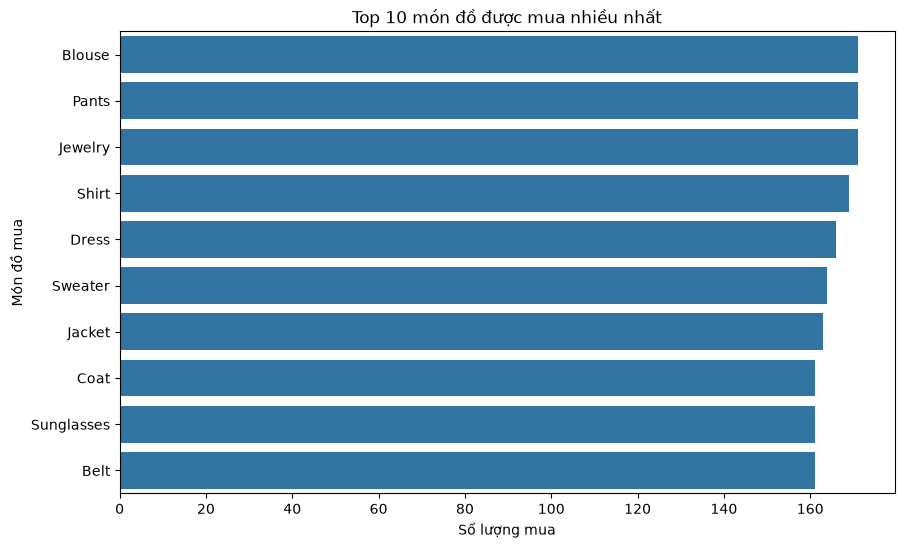

In [57]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top10_item = df['Item Purchased'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top10_item.values,
    y = top10_item.index
    
)
plt.title("Top 10 món đồ được mua nhiều nhất")
plt.xlabel("Số lượng mua")
plt.ylabel("Món đồ mua")
plt.show()

In [58]:
print(top10_item)

Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64


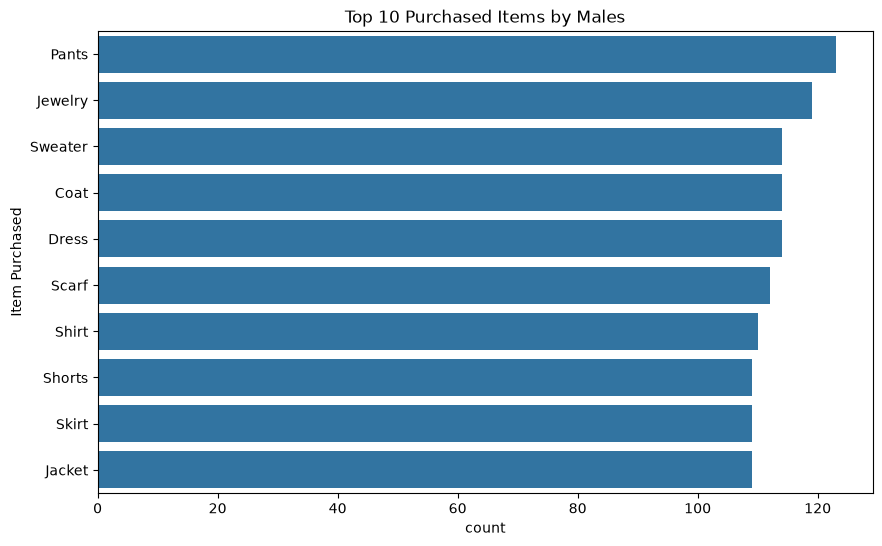

In [59]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top10_items_for_male = male_df['Item Purchased'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top10_items_for_male.values,
    y= top10_items_for_male.index
    )
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [60]:
print(top10_items_for_male)

Item Purchased
Pants      123
Jewelry    119
Sweater    114
Coat       114
Dress      114
Scarf      112
Shirt      110
Shorts     109
Skirt      109
Jacket     109
Name: count, dtype: int64


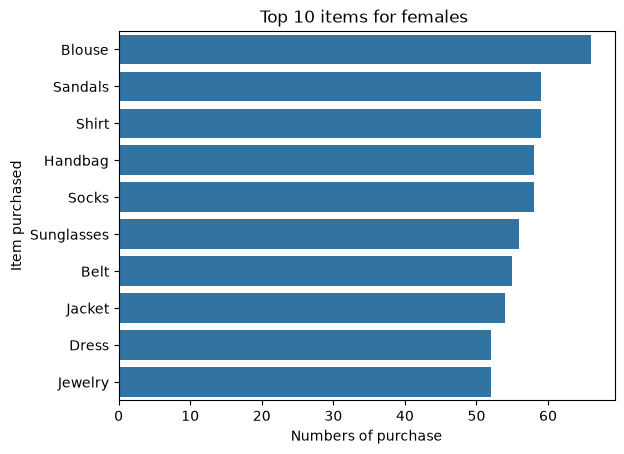

In [61]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top10_items_for_female = female_df['Item Purchased'].value_counts().nlargest(10)
sns.barplot(
    x= top10_items_for_female.values,
    y = top10_items_for_female.index
)
plt.title("Top 10 items for females ")
plt.xlabel("Numbers of purchase")
plt.ylabel("Item purchased")
plt.show()

In [62]:
# TODO: count Size with value_counts() for all customers
print("Size: ", df.shape)
display(df['Size'].value_counts())

Size:  (3900, 19)


Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [63]:
# TODO: count Size with value_counts() for male_df and female_df
display("Nam",male_df['Size'].value_counts())
display("Nữ",female_df['Size'].value_counts())

'Nam'

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

'Nữ'

Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64

### **Category**

In [64]:
# TODO: count Category with value_counts().reset_index() for all customers

### Có reset index bảng sẽ biến thành 1 data frame
ctg = df['Category'].value_counts().reset_index()
ctg


,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [65]:

### khi không dùng resetindex 
cach2= df['Category'].value_counts()
cach2

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [66]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male = male_df['Category'].value_counts().reset_index()
female = female_df['Category'].value_counts().reset_index()

print("----////----")
display(male)

print("----////----")
display(female)

----////----


,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


----////----


,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


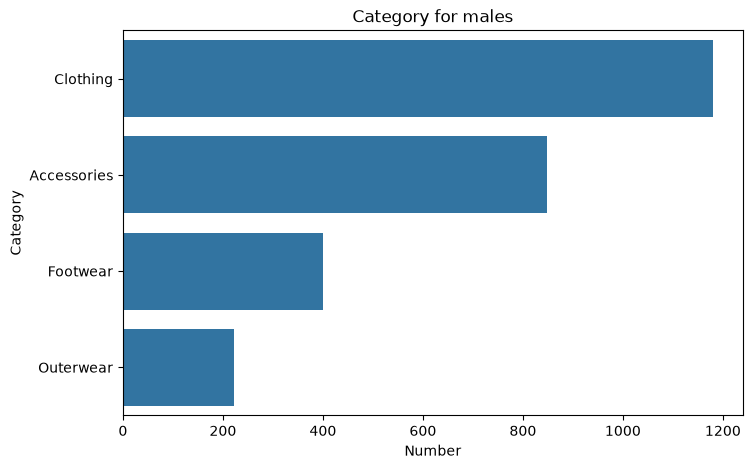

In [67]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
category = male_df['Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x = category.values,
    y = category.index
)
plt.title("Category for males") 
plt.xlabel("Number")
plt.show()


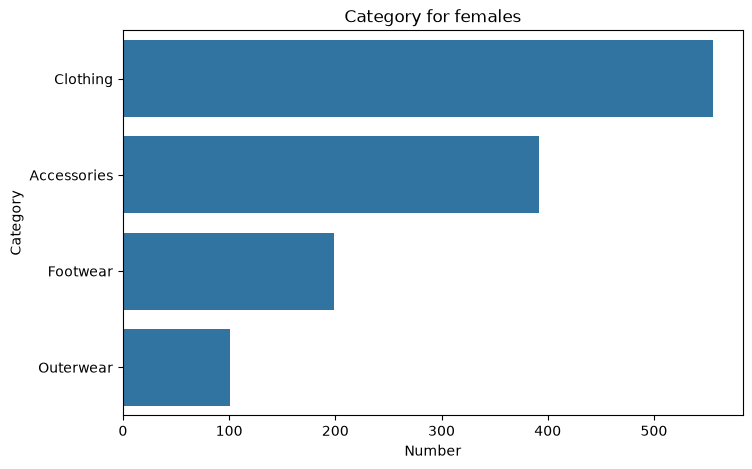

In [68]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
category = female_df['Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x = category.values,
    y = category.index
)
plt.title("Category for females") 
plt.xlabel("Number")
plt.show()

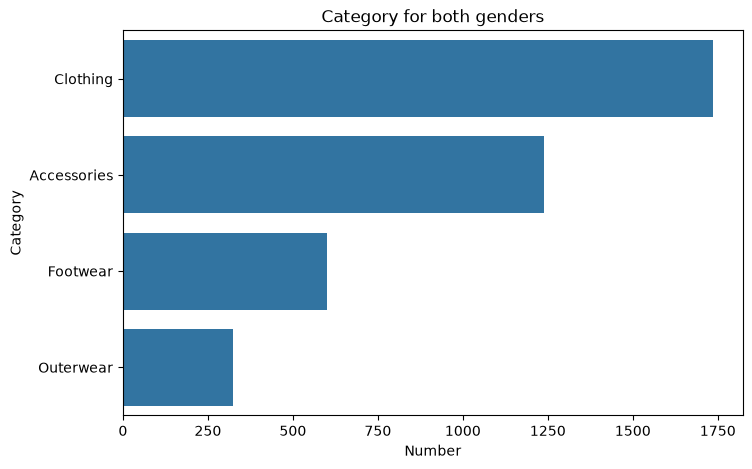

In [69]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
category =df['Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x = category.values,
    y = category.index
)
plt.title("Category for both genders") 
plt.xlabel("Number")
plt.show()


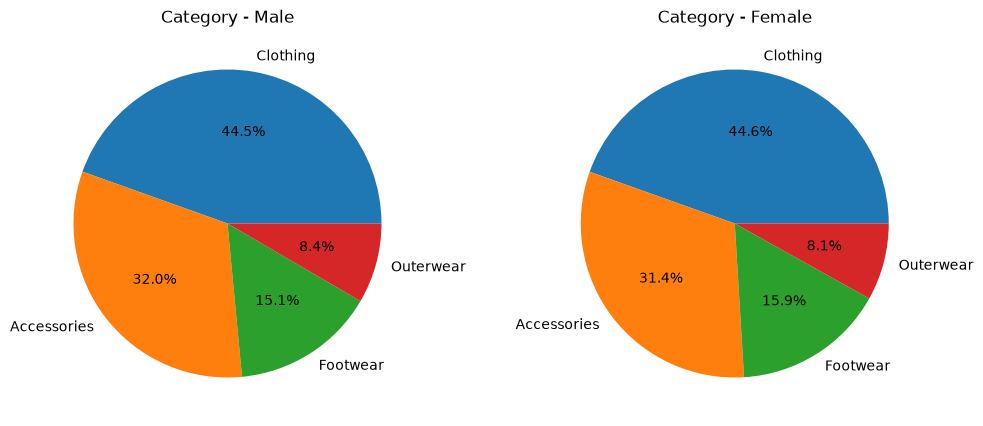

Text(0.5, 1.0, 'Female ')

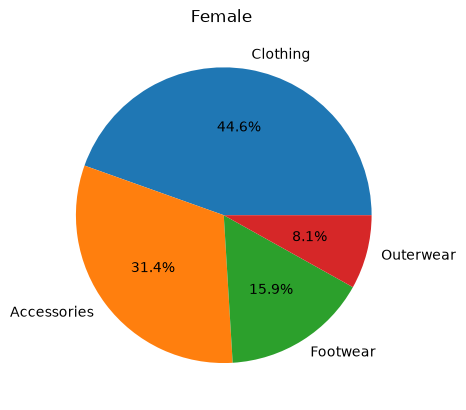

In [70]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

plt.figure(figsize=(12, 5))

# Male
plt.subplot(1, 2, 1)
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Category - Male")

# Female
plt.subplot(1, 2, 2)
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)
plt.title("Category - Female")

plt.show()
# TODO: create waffle_data_f from female_df['Category'].value_counts()

female = dict(female_df['Category'].value_counts())
plt.pie(
    female.values(),
    labels=female.keys(),
    autopct='%1.1f%%'
)
plt.title("Female ")

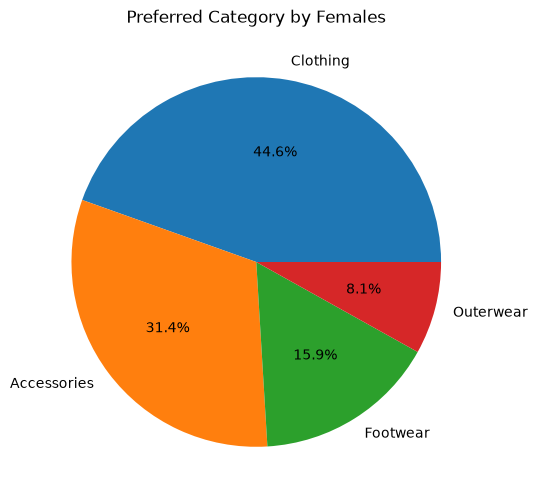

In [71]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
female = dict(female_df['Category'].value_counts())
plt.pie(
    female.values(),
    labels=female.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

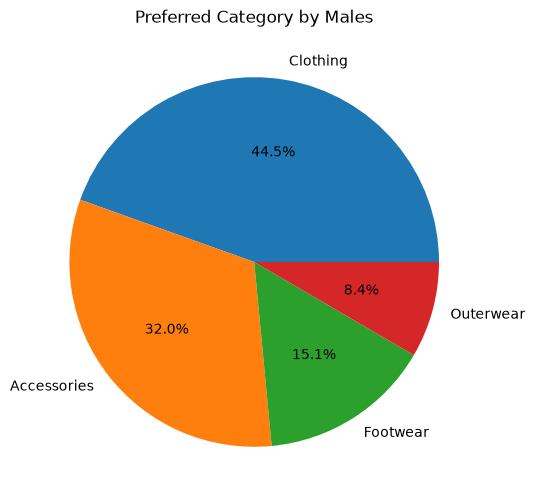

In [72]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [73]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?

female_clothes =df[(df['Category'] == 'Clothing') & (df['Gender'] == 'Female')]

display(female_clothes)

print("------/////-----")

female_mean_rating = female_clothes['Review Rating'].mean()


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,count
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly,1
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months,1
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly,1
2657,52,Female,Dress,Clothing,81,Texas,M,Pink,Summer,2.7,No,PayPal,Express,No,No,7,Credit Card,Fortnightly,1
2660,24,Female,Pants,Clothing,85,South Carolina,L,Yellow,Spring,4.9,No,Debit Card,Express,No,No,44,Venmo,Annually,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3889,57,Female,Dress,Clothing,65,Alaska,S,Yellow,Spring,3.5,No,Debit Card,Express,No,No,49,Bank Transfer,Annually,1
3890,35,Female,Shirt,Clothing,81,Nebraska,XL,Green,Winter,2.6,No,Credit Card,Standard,No,No,33,Debit Card,Annually,1
3891,36,Female,Dress,Clothing,30,Colorado,L,Peach,Winter,4.7,No,Cash,Free Shipping,No,No,6,Bank Transfer,Quarterly,1
3894,66,Female,Skirt,Clothing,78,Connecticut,L,White,Spring,3.9,No,Cash,2-Day Shipping,No,No,44,Credit Card,Every 3 Months,1


------/////-----


In [74]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?

male_clothes =df[(df['Category'] == 'Clothing') & (df['Gender'] == 'Male')]

display(male_clothes)
male_mean_rating = male_clothes['Review Rating'].mean()



,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,count
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,1
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,1
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1
6,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49,Cash,Quarterly,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2640,30,Male,Skirt,Clothing,75,Indiana,L,Olive,Summer,4.0,No,Debit Card,Store Pickup,No,No,45,Venmo,Bi-Weekly,1
2644,25,Male,Pants,Clothing,83,New Mexico,M,Turquoise,Spring,3.3,No,PayPal,Standard,No,No,4,Bank Transfer,Every 3 Months,1
2646,33,Male,T-shirt,Clothing,56,New Mexico,S,Lavender,Summer,3.9,No,Cash,Next Day Air,No,No,4,Debit Card,Every 3 Months,1
2648,51,Male,Pants,Clothing,84,Illinois,M,Gray,Spring,3.9,No,Venmo,Next Day Air,No,No,14,PayPal,Bi-Weekly,1


In [75]:
# avg_cr_m,avg_cr_f
print("Male mean rating: ", male_mean_rating)
print("Female mean rating: ", female_mean_rating)

Male mean rating:  3.7319220999153258
Female mean rating:  3.7044964028776977


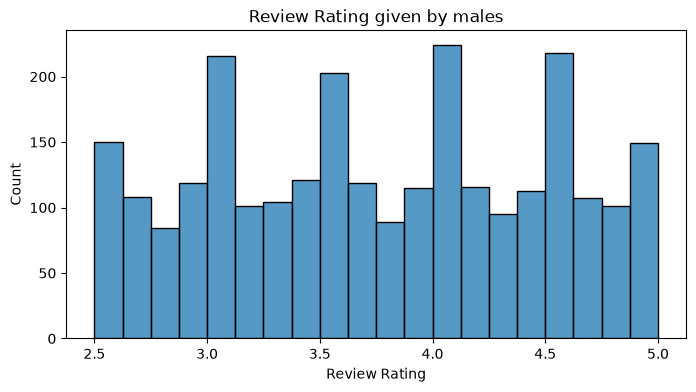

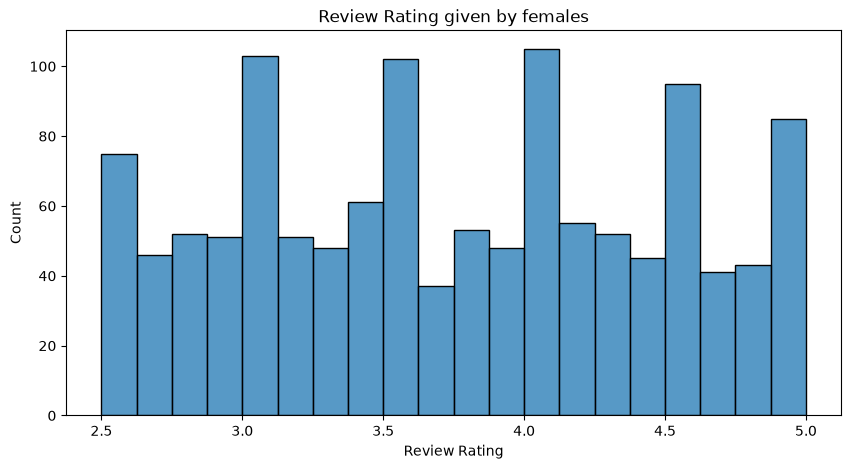

In [76]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(10,5))
sns.histplot(data=female_df,x = 'Review Rating', bins = 20)
plt.title("Review Rating given by females")
plt.show()


In [77]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
male_clothes.value_counts()

Age  Gender  Item Purchased  Category  Purchase Amount (USD)  Location       Size  Color      Season  Review Rating  Subscription Status  Payment Method  Shipping Type  Discount Applied  Promo Code Used  Previous Purchases  Preferred Payment Method  Frequency of Purchases  count
55   Male    Blouse          Clothing  53                     Kentucky       L     Gray       Winter  3.1            Yes                  Credit Card     Express        Yes               Yes              14                  Venmo                     Fortnightly             1        1
19   Male    Sweater         Clothing  64                     Maine          L     Maroon     Winter  3.1            Yes                  Bank Transfer   Express        Yes               Yes              2                   Cash                      Fortnightly             1        1
50   Male    Jeans           Clothing  73                     Massachusetts  S     Maroon     Spring  3.1            Yes                  Cash        

### **Purchase Amount (USD)**

In [78]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?

male_total_money = male_df['Purchase Amount (USD)'].sum()
# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?
female_total_money = female_df['Purchase Amount (USD)'].sum()

print("Male: ",male_total_money)
print("Female:",female_total_money)

Male:  157890
Female: 75191


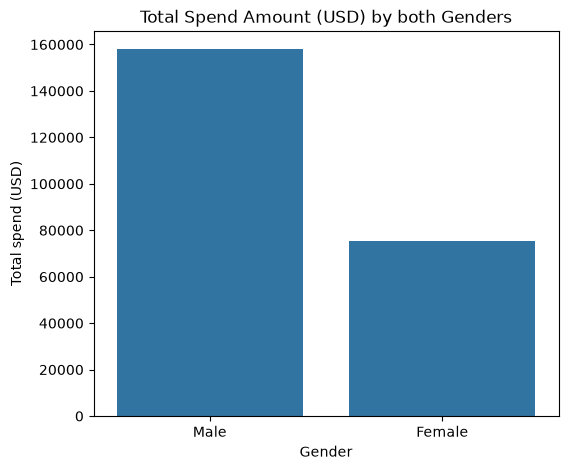

In [79]:
# TODO: plot total spend by gender with sns.barplot()
#TH: Dùng barplot mà có hai giá trị khác nhau, dùng Series gộp hai số liệu khác nhau lại
total_money = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend': [male_total_money,female_total_money]
})
plt.figure(figsize=(6, 5))
sns.barplot(
    data= total_money,
    x = 'Gender',
    y= 'Total Spend'
)

plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [80]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_f = cr_f
# ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
# co_f = ?

female_category = female_df[female_df['Category'].isin(['Clothing', 'Accessories', 'Footwear', 'Outerwear'])]
display(female_category)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [81]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_m = cr_m
# ca_m = ?
# cf_m = ?
# co_m = ?
male_category = male_df[male_df['Category'].isin(['Clothing', 'Accessories', 'Footwear', 'Outerwear'])]
display(male_category)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,60,Male,Shoes,Footwear,58,South Carolina,M,Red,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,25,Debit Card,Annually
2648,51,Male,Pants,Clothing,84,Illinois,M,Gray,Spring,3.9,No,Venmo,Next Day Air,No,No,14,PayPal,Bi-Weekly
2649,23,Male,Gloves,Accessories,21,Minnesota,M,Magenta,Fall,3.9,No,Credit Card,Store Pickup,No,No,14,Bank Transfer,Fortnightly
2650,20,Male,Socks,Clothing,35,Oregon,L,Maroon,Summer,4.2,No,PayPal,Standard,No,No,46,Credit Card,Every 3 Months


In [82]:
# TODO: create pcu dict from Promo Code Used value_counts()
#Tạo một dictionary pcu từ số lần xuất hiện của từng giá trị trong cột Promo Code Used.

pcu = dict(female_df['Promo Code Used'].value_counts())
display(pcu)
pcu


{'No': np.int64(1248)}

{'No': np.int64(1248)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

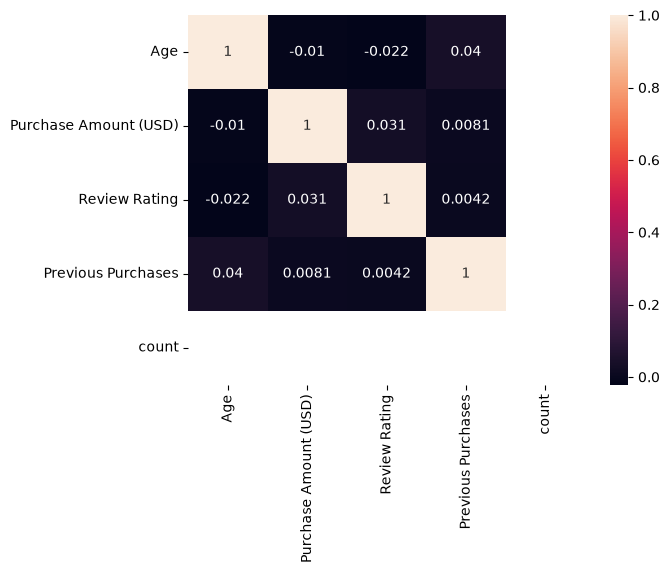

In [83]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr= df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

Dummy variables là quá trình chuyển dữ liệu dạng phân loại (như Male/Female, Clothing/Footwear...) thành các giá trị 0 và 1 để máy tính có thể xử lý và phân tích dữ liệu.

In [84]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender','Size','Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


MinMaxScaler() → thường đưa dữ liệu về khoảng 0 → 1

StandardScaler() → chuẩn hóa về mean ≈ 0, std ≈ 1

keep original columns → không xóa Purchase Amount (USD) và Age, mà tạo thêm 2 cột mới.

In [ ]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# MinMaxScaler cho Purchase Amount
minmax = MinMaxScaler()
df['Amount_minmax'] = minmax.fit_transform(df[['Purchase Amount (USD)']])

# StandardScaler cho Age
standard = StandardScaler()
df['Age_standard'] = standard.fit_transform(df[['Age']])

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [87]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 50, 100, float('inf')],
    labels=['Low', 'Medium', 'High']
)

df['Amount_bin'].value_counts()

Amount_bin
Medium    2386
Low       1514
High         0
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

In [93]:
male_df['Category'].value_counts()


Category
Clothing       1181
Accessories     848
Footwear        400
Outerwear       223
Name: count, dtype: int64

In [99]:
male_df['Item Purchased'].value_counts().head()

Item Purchased
Pants      123
Jewelry    119
Sweater    114
Coat       114
Dress      114
Name: count, dtype: int64

In [91]:
female_df['Category'].value_counts()

Category
Clothing       556
Accessories    392
Footwear       199
Outerwear      101
Name: count, dtype: int64

In [95]:
female_df['Item Purchased'].value_counts().head()

Item Purchased
Blouse     66
Sandals    59
Shirt      59
Handbag    58
Socks      58
Name: count, dtype: int64

In [101]:
male_total_money = male_df['Purchase Amount (USD)'].sum()
female_total_money = female_df['Purchase Amount (USD)'].sum()

print('Male:', male_total_money)
print('Female:', female_total_money)

Male: 157890
Female: 75191


In [103]:
male_df['Review Rating'].mean()


np.float64(3.7539592760180995)

In [104]:
female_df['Review Rating'].mean()

np.float64(3.741426282051282)

In [105]:
df['Promo Code Used'].value_counts()

Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

In [106]:
df['Promo Code Used'].value_counts(normalize=True) * 100

Promo Code Used
No     57.0
Yes    43.0
Name: proportion, dtype: float64

# TODO: write insights
-The most common item among males is **Pants**, and the most common category is **Clothing**. For females, the most common category is also **Clothing**, while the most common item is **Blouse**.

-No, males spend much more than females. Males spend a total of **$157,890**, while females spend **$75,191**.

-The review ratings for males and females are almost the same. The average rating is **3.751 for males** and **3.741 for females**.

-Promo codes are not usually used. **57%** of customers do not use a promo code, while **43%** use one.

**Caveat:** Correlation does not imply causation.


Caveat: correlation is not causation.